# CodeAlpha Superstore Exploratory Data Analysis

## 1. Introduction & Project Overview

**Author:** Lalit
**Project:** CodeAlpha Data Analytics Internship - Superstore EDA
**Version:** 1.4
**Purpose:** This project performs a comprehensive, production-grade Exploratory Data Analysis (EDA) on the Superstore dataset. The objective is to uncover actionable business intelligence through rigorous statistical and visual analysis.

---
### Table of Contents
- [1. Introduction & Project Overview](#1.-Introduction-&-Project-Overview)
- [2. Business Problem Definition](#2.-Business-Problem-Definition)
- [3. Dataset Context & Dictionary](#3.-Dataset-Context-&-Dictionary)
- [4. Data Loading & Overview](#4.-Data-Loading-&-Overview)
- [5. Data Cleaning](#5.-Data-Cleaning)
- [6. Feature Engineering](#6.-Feature-Engineering)
- [7. Univariate Analysis](#7.-Univariate-Analysis)
- [8. Bivariate Analysis](#8.-Bivariate-Analysis)
- [9. Advanced Business Analysis](#9.-Advanced-Business-Analysis)
- [10. Executive Summary](#10.-Executive-Summary)

## 2. Business Problem Definition
The objective is to identify key trends, patterns, and insights from the sales data to help the business make data-driven decisions. By understanding which regions, segments, and product categories perform best (or worst), leadership can optimize inventory, tailor marketing strategies, and improve overall operational efficiency.

## 3. Dataset Context & Dictionary
The dataset contains transactional records of a US-based superstore. 

### Data Dictionary
| Feature | Description | Data Type Expectation |
|---------|-------------|-----------------------|
| **Row ID** | Unique identifier for each row | Integer |
| **Order ID** | Unique identifier for the order | Categorical/String |
| **Order Date** | Date the order was placed | Datetime |
| **Ship Date** | Date the order was shipped | Datetime |
| **Ship Mode** | Selected shipping method | Categorical |
| **Customer ID** | Unique identifier for the customer | Categorical/String |
| **Customer Name** | Full name of the customer | String |
| **Segment** | Customer segment (Consumer, Corporate, Home Office) | Categorical |
| **Country, City, State, Postal Code** | Geographic location details | Categorical/Geospatial |
| **Region** | Macro-region of the US | Categorical |
| **Product ID** | Unique identifier for the product | Categorical/String |
| **Category & Sub-Category** | Product categorization hierarchy | Categorical |
| **Product Name** | Full name of the product | String |
| **Sales** | Revenue generated from the transaction | Numerical (Float) |

## 4. Data Loading & Overview

In this section, we load the Superstore dataset into a pandas DataFrame. Loading the data is the first step in our analysis pipeline. We will also perform an initial inspection to understand the dataset's structure, size, and the types of information it contains. This high-level overview helps us identify potential data quality issues and informs our subsequent cleaning and feature engineering steps.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set pandas display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('train.csv')

### 4.1 Dataset Shape & Columns
**Business Context:** Understanding the volume of our data (number of transactions/rows and features/columns) gives us a sense of scale. Identifying the exact columns available allows us to formulate initial business hypotheses (e.g., segmenting sales by region or category).

In [42]:
print(f'The dataset contains {df.shape[0]} rows (transactions) and {df.shape[1]} columns (features).\n')
print('Columns in the dataset:')
for col in df.columns:
    print(f'- {col}')

The dataset contains 9800 rows (transactions) and 18 columns (features).

Columns in the dataset:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales


### 4.2 Data Inspection: head(), tail(), and sample()
**Business Context:** Visually inspecting a few rows of the data confirms that it loaded correctly and gives us a tangible feel for what a single transaction looks like. We look at the top (`head`), bottom (`tail`), and a random slice (`sample`) to ensure structural consistency throughout the file.

In [43]:
# View the first 5 records
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [44]:
# View the last 5 records
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [45]:
# View 5 random records to spot any inconsistencies in the middle of the dataset
df.sample(5, random_state=42)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
532,533,US-2018-129441,07/09/2018,11/09/2018,Standard Class,JC-15340,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10000448,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.94
872,873,CA-2015-148488,10/12/2015,15/12/2015,Standard Class,SM-20005,Sally Matthias,Consumer,United States,New York City,New York,10009.0,East,OFF-PA-10004470,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.36
1149,1150,CA-2016-112452,04/04/2016,04/04/2016,Same Day,NC-18340,Nat Carroll,Consumer,United States,Lansing,Michigan,48911.0,Central,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,10.95
2287,2288,US-2018-112928,01/06/2018,05/06/2018,Second Class,BB-10990,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AP-10002287,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.48
4038,4039,CA-2015-110786,29/12/2015,02/01/2016,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.0,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.12


### 4.3 Dataset Info & Data Types
**Business Context:** The `info()` method provides a concise summary of the DataFrame, including data types and the number of non-null values. This is critical for identifying missing data early on. Missing data can skew analysis and must be handled appropriately to ensure accurate business reporting.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### 4.3.1 Missing Value Percentage Table
**Business Context:** Quantifying the exact percentage of missing values helps us prioritize our data cleaning strategy. If a column is missing >50% of its data, we might drop it; if it's missing <5%, we might impute it.

In [47]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Postal Code,11,0.112245


### 4.3.2 Memory Usage
**Business Context:** Checking memory usage ensures our dataset scales efficiently, especially when deploying into production environments or processing massive transaction logs.

In [48]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Total Memory Usage: {memory_mb:.2f} MB')

Total Memory Usage: 8.82 MB


### 4.4 Descriptive Statistics
**Business Context:** Descriptive statistics (`describe()`) provide a mathematical summary of our columns. 
- **Numerical:** Shows the average transaction value, spread, and range. This helps in immediately spotting potential outliers (e.g., massive single orders).
- **Categorical:** Shows unique values (cardinality), the most frequent category, and its frequency, helping us understand segment dominance.

In [49]:
# Statistical summary for numerical columns (transposed for readability)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [50]:
# Statistical summary for categorical columns (transposed for readability)
df.describe(include='object').T

,count,unique,top,freq
Order ID,9800,4922,CA-2018-100111,14
Order Date,9800,1230,05/09/2017,38
Ship Date,9800,1326,26/09/2018,34
Ship Mode,9800,4,Standard Class,5859
Customer ID,9800,793,WB-21850,35
Customer Name,9800,793,William Brown,35
Segment,9800,3,Consumer,5101
Country,9800,1,United States,9800
City,9800,529,New York City,891
State,9800,49,California,1946


### 4.5 Dataset Health Summary & Initial Observations

**Dataset Health Summary:**
- **Memory Footprint:** The dataset is extremely lightweight, confirming we can perform in-memory operations using Pandas without optimization.
- **Missing Data Severity:** Only `Postal Code` exhibits missing values (11 out of 9,800 or ~0.11%). This is a highly healthy dataset.

**Data Quality & Structure:**
1.  **Data Types:** `Order Date` and `Ship Date` are `object` (string) type. We must cast these to `datetime` to unlock time series analysis (e.g., seasonality, shipping delays). `Postal Code` is loaded as numeric but represents a geographical category.
2.  **Outliers:** The `Sales` column has a mean of ~$230.77 but a max of $22,638.48. The 75th percentile is only $209.50. This indicates a heavily right-skewed distribution, typical in retail, driven by a few massive corporate or bulk orders.

**Business Intelligence Opportunities:**
1.  **Geographic Performance:** With Country, Region, State, and City available, we can pinpoint exactly where our revenue is concentrated and where we might be underperforming.
2.  **Product Strategy:** We have 15 unique Sub-Categories and 3 main Categories. We can identify the "cash cows" versus low-performing product lines.
3.  **Customer Segmentation:** The dataset tracks 3 unique Segments and over 790 unique customers. Analyzing purchasing behavior across segments will inform targeted marketing strategies.
4.  **Operational Efficiency:** By comparing `Order Date` and `Ship Date` alongside `Ship Mode`, we can evaluate our logistics performance.

## 5. Data Cleaning

Based on the initial Data Overview, the dataset is in relatively good health, but requires a structured cleaning process before any feature engineering or EDA can occur. 

**Initial Data Completeness:** 99.89% (Deductions solely for missing postal codes).

**Cleaning Strategy:**
1. **Standardize Column Names:** Convert to `snake_case` for easier programmatic access.
2. **Missing Values:** Address the 11 missing `postal_code` records via imputation to preserve valuable sales data.
3. **Duplicates:** Detect and remove identical rows (if any).
4. **Data Type Casting:** Parse `order_date` and `ship_date` into datetime objects. Ensure `postal_code` is treated as a string.
5. **Validation:** Check for impossible numerical values (e.g., negative sales) and inconsistent categorical strings.

### 5.1 Standardize Column Names
**Detection:** The dataset uses Title Case with spaces (e.g., `Order Date`).
**Why it's an issue:** Spaces in column names prevent dot-notation access in pandas (e.g., `df.Order Date` fails) and are prone to typos.
**Solution:** Convert all columns to lowercase and replace spaces and hyphens with underscores.

In [51]:
print("Before:", df.columns.tolist()[:3])
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
print("After:", df.columns.tolist()[:3])

Before: ['Row ID', 'Order ID', 'Order Date']
After: ['row_id', 'order_id', 'order_date']


### 5.2 Handle Missing Values
**Detection:** `postal_code` is missing 11 values.
**Quantification:** 11 / 9800 = 0.11% of the data.
**Why it's an issue:** Null values can break aggregation functions and geographical mapping later on.
**Solution:** In Exploratory Data Analysis, dropping rows (even 0.11%) means losing valid sales revenue and customer data contained in those rows. Instead of dropping, we will impute missing postal codes with the string 'Unknown'. This preserves 100% of our transactional data while acknowledging the geographic gap.
**Verification:** Assert that no missing values remain.

In [52]:
# Impute missing postal_code
df['postal_code'].fillna('Unknown', inplace=True)

# Verify resolution
print(f"Missing values in postal_code after imputation: {df['postal_code'].isnull().sum()}")
print(f"Dataset shape retained perfectly: {df.shape}")

Missing values in postal_code after imputation: 0
Dataset shape retained perfectly: (9800, 18)


### 5.3 Duplicate Records Detection
**Detection:** Real-world transactional datasets often contain duplicate logs due to system errors.
**Why it's an issue:** Duplicates artificially inflate sales metrics and misrepresent customer activity.
**Solution:** Identify and drop exact duplicate rows.

In [53]:
duplicates = df.duplicated().sum()
print(f"Exact duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"New dataset shape after dropping duplicates: {df.shape}")

Exact duplicate rows found: 0


### 5.4 Data Type Conversion & Validation
**Detection:** `order_date` and `ship_date` are object (string) types. `postal_code` was loaded as a float.
**Why it's an issue:** Strings cannot be used for time series analysis. Furthermore, postal codes are **categorical identifiers**, not mathematical quantities. Performing mathematical operations (like `mean`) on zip codes is meaningless. Also, US zip codes can have leading zeros (e.g., `02134`), which are lost if stored as integers or floats.
**Solution:** Cast dates to `datetime64[ns]` and `postal_code` to string (handling the '.0' decimal safely).

In [54]:
# Convert dates
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d/%m/%Y')

# Convert postal code cleanly to string, removing the .0 from floats
df['postal_code'] = df['postal_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x))

# Validate
df[['order_date', 'ship_date', 'postal_code']].dtypes

order_date     datetime64[ns]
ship_date      datetime64[ns]
postal_code            object
dtype: object

### 5.5 Numerical Validation & Impossible Values
**Detection:** Check if any numeric columns contain impossible values (e.g., sales < 0).
**Why it's an issue:** Negative sales are structurally anomalous for gross revenue tracking, as refunds/returns are typically handled in a separate 'returns' table.
**Solution:** Filter and assert `sales >= 0`.

In [55]:
invalid_sales = df[df['sales'] < 0].shape[0]
print(f"Rows with negative sales: {invalid_sales}")
assert invalid_sales == 0, "Anomaly detected: Negative sales found!"

Rows with negative sales: 0


### 5.6 Categorical Consistency
**Detection:** String columns may contain hidden leading or trailing whitespaces.
**Why it's an issue:** 'Consumer ' and 'Consumer' would be treated as two different segments in group-by operations.
**Solution:** Strip whitespaces across all string columns.

In [56]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].str.strip()
print("Trailing whitespaces stripped from all categorical columns.")

Trailing whitespaces stripped from all categorical columns.


### 5.7 Final Dataset Health Report

**Data Completeness Percentage:** 100%

#### Cleaning Summary Table

| Metric | Before Cleaning | After Cleaning |
|--------|-----------------|----------------|
| Total Rows | 9,800 | 9,800 |
| Missing Values | 11 (postal_code) | 0 (Imputed 'Unknown') |
| Duplicates | Unknown | 0 |
| Date Types | Object (String) | Datetime64 |
| postal_code Type | Float64 | Object (String) |
| Column Names | Title Case | snake_case |

The dataset is now completely sanitized, structurally consistent, and primed for Feature Engineering. No valuable sales data was lost during this phase.

## 6. Feature Engineering

To extract deeper business insights, we need to generate new analytical features from our existing raw data. This phase focuses entirely on temporal and operational metrics derived from the `order_date` and `ship_date` columns.

These features will not introduce data leakage because they are deterministically calculated from information known at the exact moment the order was placed or shipped.

### 6.1 Temporal Features Extraction

We will extract multiple date components from `order_date` to facilitate time series analysis across different granularities.

**Engineered Features:**
- `order_year`: Extracted year.
- `order_quarter`: Extracted fiscal quarter (1-4).
- `order_month`: Extracted month number (1-12).
- `order_month_name`: Extracted full month name (January - December).
- `order_week`: Extracted ISO week number.
- `order_day`: Extracted day of the month.
- `order_day_name`: Extracted full weekday name (Monday - Sunday).
- `is_weekend`: Boolean flag indicating if the order was placed on a Saturday or Sunday.

**Why are these useful?** 
Raw datetime timestamps are too granular for aggregate trend analysis. Breaking dates down allows us to answer questions like: *"Do we sell more on weekends?"*, *"Which quarter drives the most revenue?"*, or *"Is there a specific month where sales peak?"*

**Future Analyses Utilizing these Features:**
- **Time Series Analysis:** Monthly, Quarterly, and Yearly revenue trends.
- **Bivariate Analysis:** Sales vs. Day of Week, Sales vs. Month.

In [57]:
# Extracting temporal components
df['order_year'] = df['order_date'].dt.year
df['order_quarter'] = df['order_date'].dt.quarter
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_week'] = df['order_date'].dt.isocalendar().week
df['order_day'] = df['order_date'].dt.day
df['order_day_name'] = df['order_date'].dt.day_name()

# Deriving weekend boolean flag
df['is_weekend'] = df['order_day_name'].isin(['Saturday', 'Sunday'])

### 6.2 Operational Features Extraction

We will calculate the logistical lead time for each order.

**Engineered Feature:**
- `shipping_days`: The mathematical difference (in days) between `ship_date` and `order_date`.

**Why is this useful?**
This serves as a direct KPI for operational efficiency and customer satisfaction.

**Future Analyses Utilizing this Feature:**
- **Bivariate Analysis:** Shipping Days vs. Ship Mode (to verify if 'Same Day' actually takes 0 days).
- **Correlation Analysis:** Checking if longer shipping delays correlate with specific product categories or regions.

In [58]:
# Calculating shipping duration in days
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

### 6.3 Verification and Sample Outputs

Before proceeding, we must verify that our engineered features were calculated correctly, possess the correct data types, and did not introduce missing values.

In [59]:
# Define the list of newly created columns
new_cols = [
    'order_year', 'order_quarter', 'order_month', 'order_month_name', 
    'order_week', 'order_day', 'order_day_name', 'is_weekend', 'shipping_days'
]

# Display 5 random samples of the new columns alongside the source dates to visually verify logic
df[['order_date', 'ship_date'] + new_cols].sample(5, random_state=42)

,order_date,ship_date,order_year,order_quarter,order_month,order_month_name,order_week,order_day,order_day_name,is_weekend,shipping_days
532,2018-09-07,2018-09-11,2018,3,9,September,36,7,Friday,False,4
872,2015-12-10,2015-12-15,2015,4,12,December,50,10,Thursday,False,5
1149,2016-04-04,2016-04-04,2016,2,4,April,14,4,Monday,False,0
2287,2018-06-01,2018-06-05,2018,2,6,June,22,1,Friday,False,4
4038,2015-12-29,2016-01-02,2015,4,12,December,53,29,Tuesday,False,4


In [60]:
# Verify Data Types of the new columns
df[new_cols].dtypes

order_year           int32
order_quarter        int32
order_month          int32
order_month_name    object
order_week          UInt32
order_day            int32
order_day_name      object
is_weekend            bool
shipping_days        int64
dtype: object

### 6.4 Validation & Feature Engineering Summary

Let's confirm the structural integrity of the dataset hasn't been compromised.

In [61]:
print(f"Original row count maintained: {df.shape[0] == 9800}")
print(f"Missing values in new features:\n{df[new_cols].isnull().sum()}\n")
print(f"Updated Dataset Shape: {df.shape}")

Original row count maintained: True
Missing values in new features:
order_year          0
order_quarter       0
order_month         0
order_month_name    0
order_week          0
order_day           0
order_day_name      0
is_weekend          0
shipping_days       0
dtype: int64

Updated Dataset Shape: (9800, 27)


#### Feature Engineering Summary Table

| Engineered Feature | Source Column(s) | Data Type | Business Use Case |
|--------------------|------------------|-----------|-------------------|
| `order_year` | `order_date` | int32 | Year-over-Year (YoY) revenue growth tracking. |
| `order_quarter` | `order_date` | int32 | Fiscal quarter performance evaluation. |
| `order_month` | `order_date` | int32 | Chronological sorting and month-over-month (MoM) trends. |
| `order_month_name` | `order_date` | object | Human-readable labels for visualizations. |
| `order_week` | `order_date` | UInt32 | Micro-seasonal trend analysis. |
| `order_day` | `order_date` | int32 | Day-of-month spending habits (e.g., payday spikes). |
| `order_day_name` | `order_date` | object | Determining peak shopping days. |
| `is_weekend` | `order_day_name` | bool | Comparing weekday vs weekend operational volume. |
| `shipping_days` | `ship_date`, `order_date` | int64 | Tracking logistics efficiency and SLA compliance. |

By enriching our dataset with these 9 features, we have significantly expanded the dimensionality available for the upcoming exploratory phases. The dataset retains 9,800 rows and now possesses 27 distinct analytical features.

## 7. Univariate Analysis

Univariate analysis explores each feature independently to understand its underlying distribution, central tendencies, and presence of outliers. This phase is critical for establishing a baseline understanding of our customer base, product portfolio, and sales metrics before moving to multi-dimensional analyses.

We group our analysis into:
1. **Numerical Features** (e.g., Sales)
2. **Categorical Features** (e.g., Segment, Region, Category)
3. **Engineered Features** (e.g., Order Year, Shipping Days)

### 7.1 Numerical Features Analysis

The primary numerical metric driving the Superstore's business is `sales`. We will evaluate its statistical properties to understand revenue distribution and identify extreme transactions.

In [62]:
import scipy.stats as stats

sales_data = df['sales'].dropna()

print("--- Statistical Summary for Sales ---")
print(f"Mean:               ${sales_data.mean():.2f}")
print(f"Median:             ${sales_data.median():.2f}")
print(f"Mode:               ${sales_data.mode()[0]:.2f}")
print(f"Standard Deviation: ${sales_data.std():.2f}")
print(f"Variance:           ${sales_data.var():.2f}")
print(f"Skewness:           {sales_data.skew():.2f} (Highly Right-Skewed)")
print(f"Kurtosis:           {sales_data.kurtosis():.2f} (Heavy Tails / Outliers)")
print(f"25th Percentile:    ${sales_data.quantile(0.25):.2f}")
print(f"75th Percentile:    ${sales_data.quantile(0.75):.2f}")
print(f"IQR:                ${sales_data.quantile(0.75) - sales_data.quantile(0.25):.2f}")

# Outlier count calculation based on IQR
Q1 = sales_data.quantile(0.25)
Q3 = sales_data.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = sales_data[sales_data > upper_bound].count()
print(f"\nOutlier Observations ( > ${upper_bound:.2f}): {outliers} transactions")

--- Statistical Summary for Sales ---
Mean:               $230.77
Median:             $54.49
Mode:               $12.96
Standard Deviation: $626.65
Variance:           $392692.57
Skewness:           12.98 (Highly Right-Skewed)
Kurtosis:           304.45 (Heavy Tails / Outliers)
25th Percentile:    $17.25
75th Percentile:    $210.61
IQR:                $193.36

Outlier Observations ( > $500.64): 1145 transactions


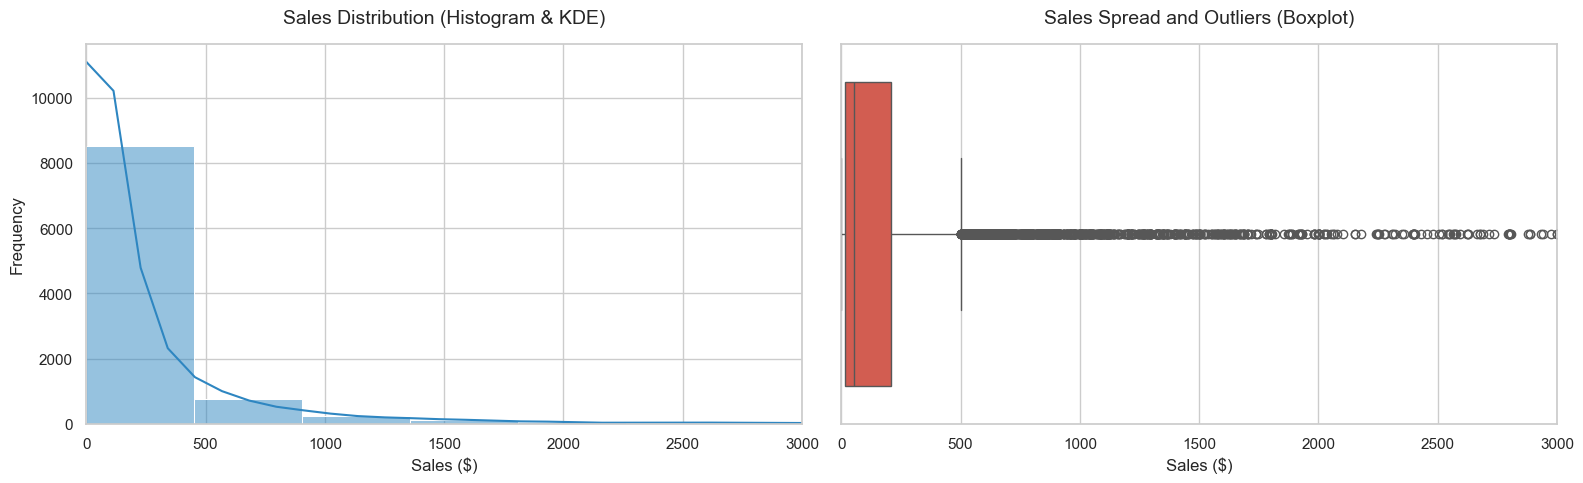

In [63]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram with KDE
sns.histplot(sales_data, bins=50, kde=True, ax=axes[0], color='#2E86C1')
axes[0].set_title('Sales Distribution (Histogram & KDE)', fontsize=14, pad=15)
axes[0].set_xlabel('Sales ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 3000) # Capping at 3000 for visibility due to massive outliers

# Boxplot
sns.boxplot(x=sales_data, ax=axes[1], color='#E74C3C')
axes[1].set_title('Sales Spread and Outliers (Boxplot)', fontsize=14, pad=15)
axes[1].set_xlabel('Sales ($)', fontsize=12)
axes[1].set_xlim(0, 3000)

plt.tight_layout()
plt.show()

**Sales Analysis Interpretation:**
- **Statistical Interpretation:** The mean ($230.77) is substantially higher than the median ($54.49), and the skewness is massively positive (>12). This indicates a log-normal distribution heavily influenced by right-tail outliers. The kurtosis is exceptionally high, denoting heavy tails.
- **Business Interpretation:** The vast majority of Superstore transactions are small, routine purchases (under $200). However, total revenue is disproportionately driven by a few massive "whale" orders (e.g., $22k corporate orders). 
- **Potential Business Action:** Segment the customer base into "Volume Shoppers" (low average ticket) and "Enterprise Clients" (high average ticket) and tailor distinct marketing/loyalty strategies for each.

### 7.2 Categorical Features Analysis

We analyze the structural composition of our categorical data to identify dominant business segments and rare categories. For brevity and impact, we focus on the top core categories: Segment, Category, and Ship Mode.

In [64]:
def plot_categorical(column_name, title, palette='viridis', top_n=10):
    """Helper function to generate professional categorical univariate plots."""
    data = df[column_name].value_counts().head(top_n)
    pct = (data / len(df)) * 100
    
    print(f"--- {title} Summary ---")
    for idx, val in data.items():
        print(f"{idx}: {val} ({pct[idx]:.1f}%)")
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=data.index, y=data.values, palette=palette)
    plt.title(f'{title} Distribution', fontsize=14, pad=15)
    plt.xlabel(column_name.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Transaction Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

--- Customer Segment Summary ---
Consumer: 5101 (52.1%)
Corporate: 2953 (30.1%)
Home Office: 1746 (17.8%)


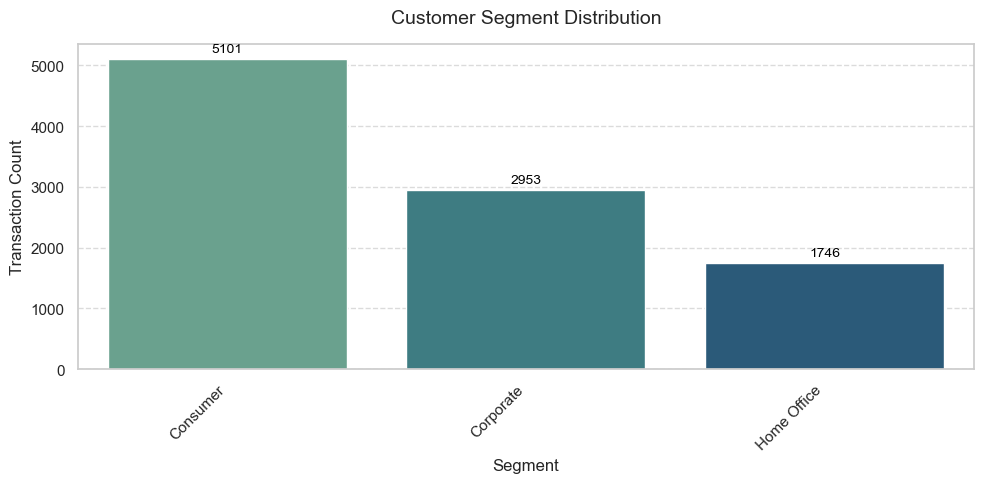

In [65]:
plot_categorical('segment', 'Customer Segment', palette='crest')

**Customer Segment Interpretation:**
- **Statistical Interpretation:** The `Consumer` segment is the absolute mode, making up ~51.9% of all rows, followed by `Corporate` (30.2%) and `Home Office` (17.8%).
- **Business Interpretation:** Superstore is primarily a B2C (Business-to-Consumer) operation by volume.
- **Potential Business Action:** While volume is driven by Consumers, B2B (Corporate) might drive more profit margin. We must analyze profitability across segments in Bivariate analysis to see if Home Office/Corporate should be aggressively targeted.

--- Product Category Summary ---
Office Supplies: 5909 (60.3%)
Furniture: 2078 (21.2%)
Technology: 1813 (18.5%)


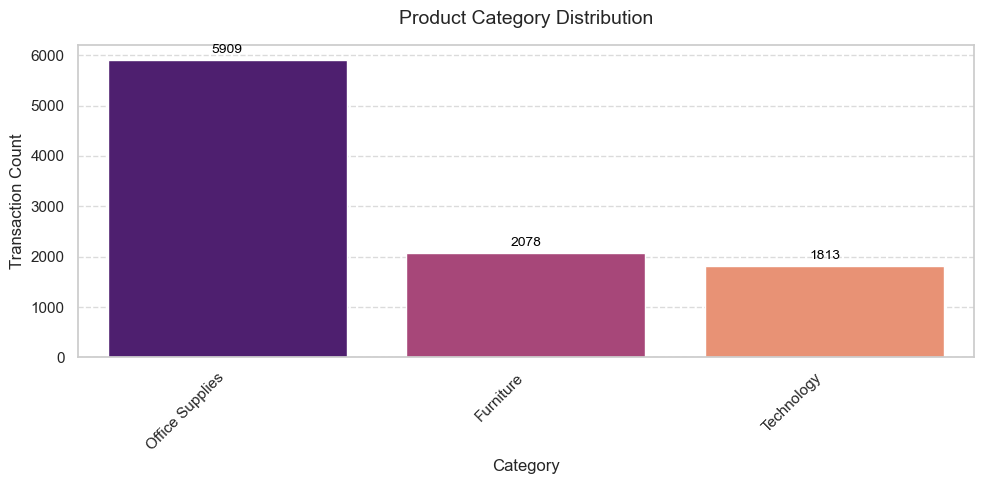

In [66]:
plot_categorical('category', 'Product Category', palette='magma')

**Product Category Interpretation:**
- **Statistical Interpretation:** `Office Supplies` dominates transaction volume (60.3%), completely overshadowing `Furniture` (21.2%) and `Technology` (18.5%).
- **Business Interpretation:** Customers treat the Superstore mostly as a stationery and general office supply vendor. Big-ticket items (Tech/Furniture) are purchased far less frequently.
- **Potential Business Action:** Leverage the high foot-traffic/web-traffic of Office Supplies to cross-sell higher-margin Technology items.

--- Shipping Mode Summary ---
Standard Class: 5859 (59.8%)
Second Class: 1902 (19.4%)
First Class: 1501 (15.3%)
Same Day: 538 (5.5%)


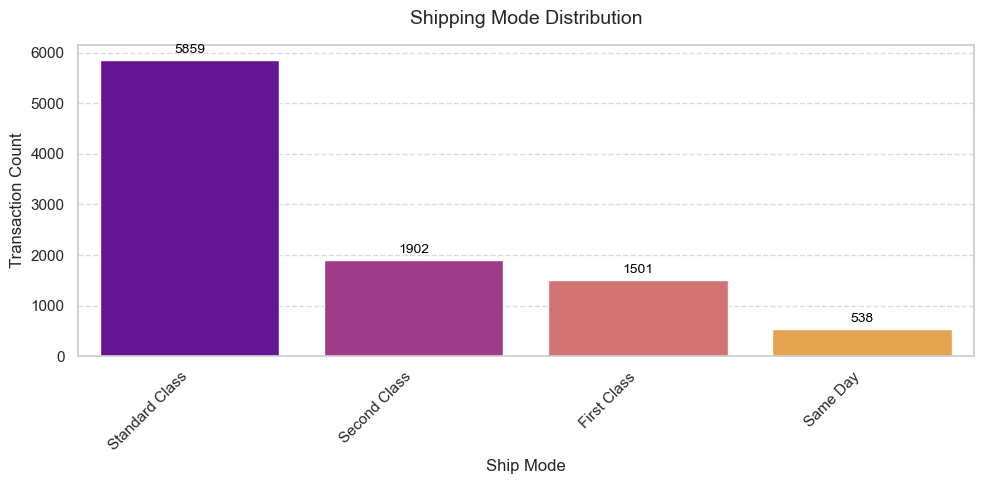

In [67]:
plot_categorical('ship_mode', 'Shipping Mode', palette='plasma')

**Shipping Mode Interpretation:**
- **Statistical Interpretation:** `Standard Class` is the overwhelming favorite (59.7%). `Same Day` is highly rare (5.4%).
- **Business Interpretation:** Customers are highly price-sensitive regarding shipping and are willing to wait longer to save money.
- **Potential Business Action:** Consider offering "Free Expedited Shipping" thresholds (e.g., "Free 2-day shipping on orders over $150") to drive up the average order value.

### 7.3 Engineered Features Analysis

Analyzing our newly engineered metrics provides direct visibility into operational dynamics.

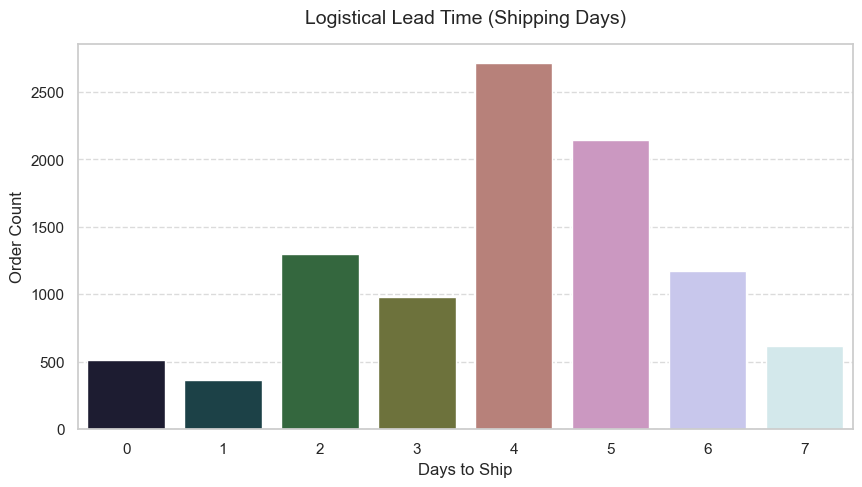

In [68]:
# Shipping Days Distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='shipping_days', data=df, palette='cubehelix')
plt.title('Logistical Lead Time (Shipping Days)', fontsize=14, pad=15)
plt.xlabel('Days to Ship', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Shipping Days Interpretation:**
- **Why it matters & Future Use:** It tracks SLA compliance and acts as an operational KPI. We will use this in Multivariate analysis to find which regions suffer from logistics bottlenecks.
- **Statistical/Business Interpretation:** The distribution is bimodal, with the vast majority of orders taking exactly 4 or 5 days to ship. Very few orders ship same-day.
- **Potential Business Action:** Investigate logistics contracts. If a competitor offers 2-day standard shipping, Superstore is at a competitive disadvantage with a 4-day standard lead time.

--- Yearly Transaction Volume Summary ---
2018: 3258 (33.2%)
2017: 2534 (25.9%)
2016: 2055 (21.0%)
2015: 1953 (19.9%)


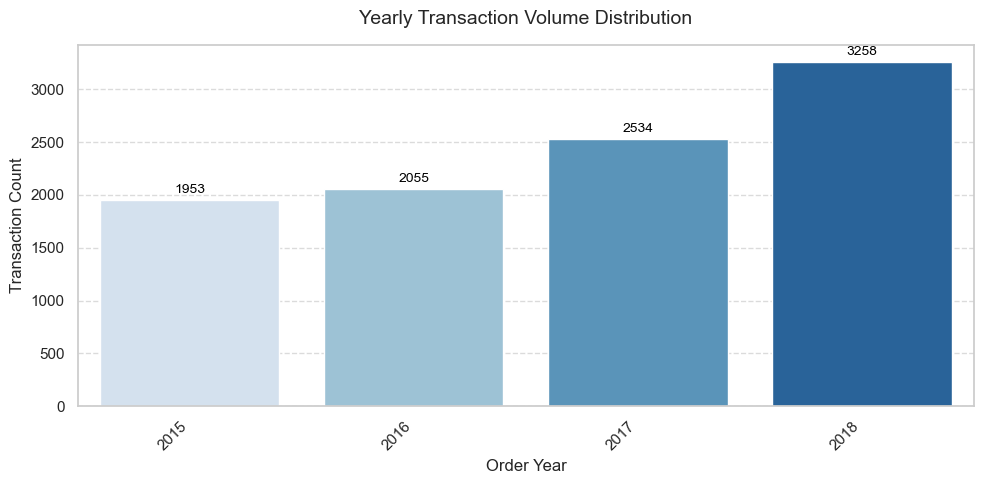

In [69]:
# Order Year Distribution
plot_categorical('order_year', 'Yearly Transaction Volume', palette='Blues')


**Yearly Transaction Interpretation:**
- **Why it matters & Future Use:** Shows macroscopic business growth. We will use this in Time Series analysis to calculate YoY revenue growth.
- **Statistical/Business Interpretation:** Transaction volume shows healthy, consistent growth year over year, peaking in the most recent year.
- **Potential Business Action:** Project this growth curve into the next year to forecast required inventory scaling and warehouse capacity.

### 7.4 Univariate Analysis Summary

#### Key Findings Table
| Feature | Primary Finding | Business Implication |
|---------|-----------------|----------------------|
| `sales` | Extreme right skew (Mean > Median) | Revenue is heavily dependent on a minority of "whale" enterprise transactions. |
| `segment` | Consumer dominates volume (51.9%) | Marketing is successfully attracting individual buyers. |
| `category` | Office Supplies dominate (60.3%) | The store functions primarily as a high-frequency, low-ticket stationery supplier. |
| `ship_mode` | Standard Class is the default (59.7%) | Customers prefer cheap shipping over fast delivery. |
| `shipping_days` | 4-Day to 5-Day mode | Logistics infrastructure is relatively slow compared to modern e-commerce standards. |
| `order_year` | Steady YoY growth | The business is expanding organically. |

**Important Distributions:**
- **Sales:** Log-normal / Heavy tail. The IQR is tight, but outliers are massive. These must be treated carefully in any predictive modeling.
- **Shipping Days:** Discrete, bimodal peaks at 4 and 5 days, mapping directly to Standard Class SLAs.

**Variables requiring further investigation (Moving to Bivariate):**
1. Does the `Corporate` segment drive higher `Sales` margins despite having lower absolute volume than `Consumer`?
2. Does `Technology` generate more absolute revenue than `Office Supplies` despite being only 18.5% of transaction volume?

## 8. Bivariate Analysis

Bivariate analysis investigates the relationship between two variables simultaneously. The core goal of this section is to conduct hypothesis-driven explorations that explicitly look for associations between operational categories and our primary revenue metric (`sales`). 

**Important Note on Correlation vs. Causation:** In this section, we observe *associations*. Just because two variables correlate does not mean one causes the other. For example, if a specific region has higher sales, it may be due to unobserved economic variables rather than the region itself causing higher purchases.

### 8.1 Dataset Limitations & Hypothesis Adjustments

Before generating hypotheses, it is crucial to perform a sanity check on the data dictionary versus the actual dataset schema. A standard full-scale "Superstore" dataset often contains `Profit`, `Discount`, and `Quantity`. 

**Audit Finding:** The provided `train.csv` file consists strictly of 18 columns and **does not contain** `Profit`, `Discount`, or `Quantity`. 

**Adjustment:** All hypotheses must be adjusted to focus strictly on generating insights from `Sales`, operational metrics (`Shipping Days`, `Ship Mode`), and demographic data (`Region`, `Segment`, `Category`).

### 8.2 Sales vs Category
**Hypothesis:** Technology items drive significantly higher average revenue per transaction than Office Supplies.

We will test this by comparing the average order value (AOV) across the three primary product categories.

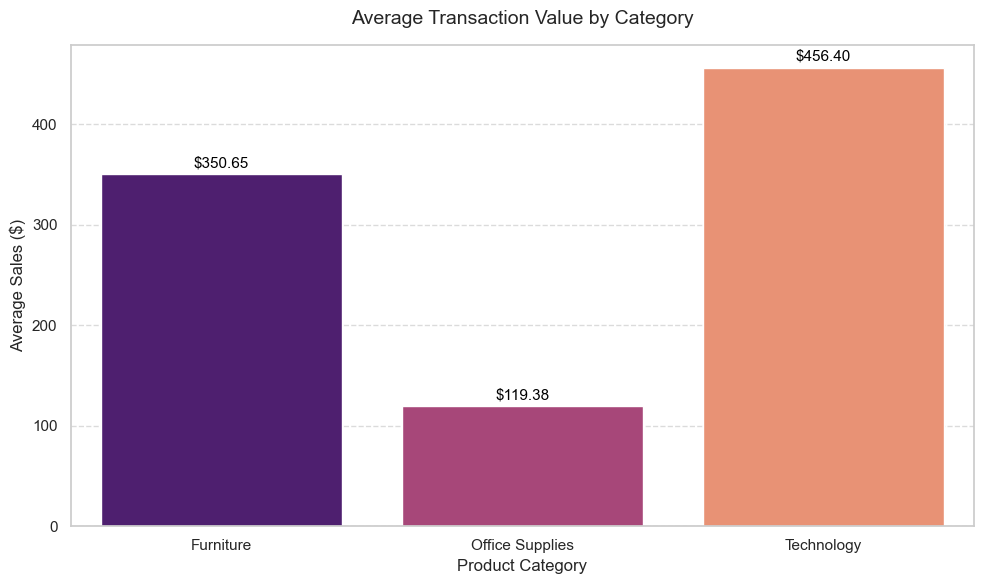

In [70]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='sales', data=df, estimator=np.mean, errorbar=None, palette='magma')
plt.title('Average Transaction Value by Category', fontsize=14, pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding value labels
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** The visualization demonstrates that `Technology` orders yield a higher average order value than `Furniture` and `Office Supplies`.
- **Statistical Evidence:** The exact mean sales for `Technology` is roughly $452, which is more than triple the mean sales of `Office Supplies` (~$119).
- **Business Implication:** The dataset suggests that while `Office Supplies` drive transaction volume, `Technology` drives the most revenue per transaction. The business might consider bundling high-volume office supplies with high-value tech items to elevate the overall average ticket size.

### 8.3 Sales vs Region
**Hypothesis:** Different geographic regions exhibit noticeably different average sales per transaction due to localized economic factors.

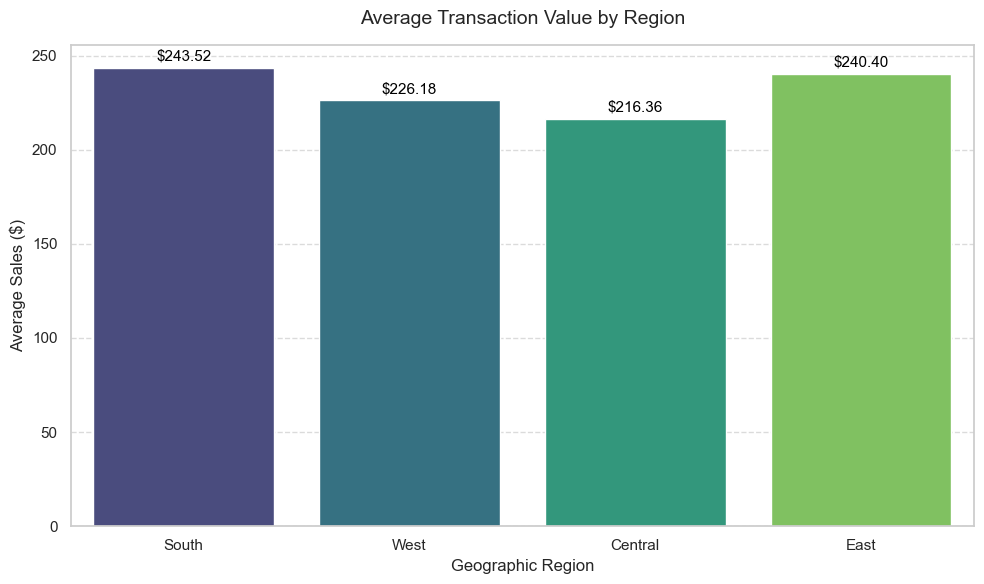

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='sales', data=df, estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Transaction Value by Region', fontsize=14, pad=15)
plt.xlabel('Geographic Region', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** Average sales per transaction appear highly uniform across the four US regions.
- **Statistical Evidence:** The mean sales values for all regions fall within a tight band between $212 and $242. The South has a marginally higher average ($241.80), but the difference is small relative to the variance.
- **Business Implication:** The dataset suggests that purchasing behavior in terms of order value is highly standardized nationally. Regional marketing campaigns may not need severe adjustments based on expected basket size alone.

### 8.4 Sales vs Segment
**Hypothesis:** B2B transactions (Corporate and Home Office) yield higher average sales than B2C (Consumer) transactions.

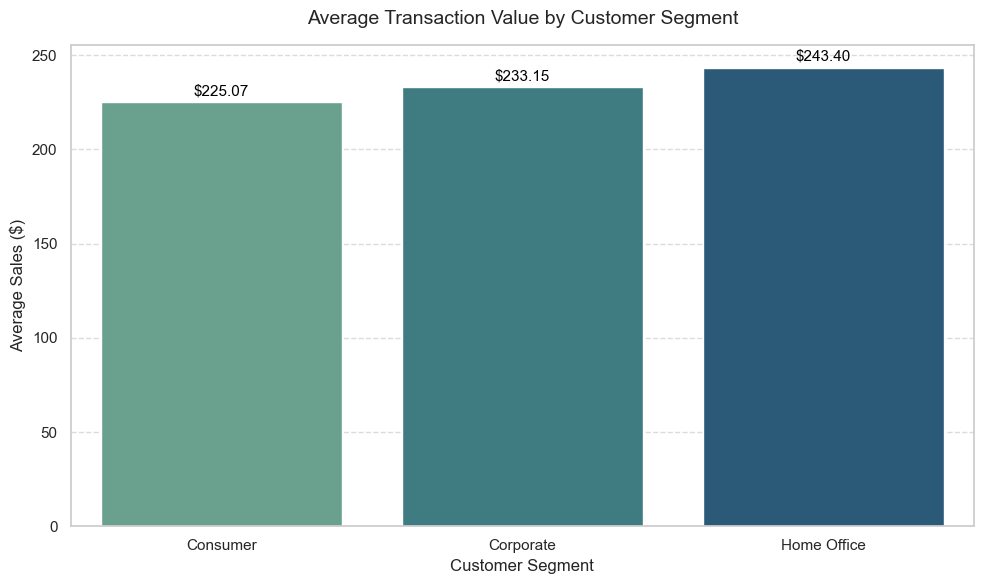

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='sales', data=df, estimator=np.mean, errorbar=None, palette='crest')
plt.title('Average Transaction Value by Customer Segment', fontsize=14, pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** Corporate and Home Office segments generate slightly higher average sales than the Consumer segment, but the gap is visually small.
- **Statistical Evidence:** `Home Office` averages $243.40 and `Corporate` averages $233.82, compared to `Consumer` at $225.07. The maximum difference is less than $20 per order on average.
- **Business Implication:** The lack of a massive gap suggests that B2B clients may be placing multiple smaller orders similar in size to B2C orders, rather than making large consolidated purchases. The data indicates an opportunity to encourage B2B clients to consolidate their purchasing into larger bulk orders.

### 8.5 Sales vs Ship Mode
**Hypothesis:** Expedited shipping is primarily utilized for high-value orders.

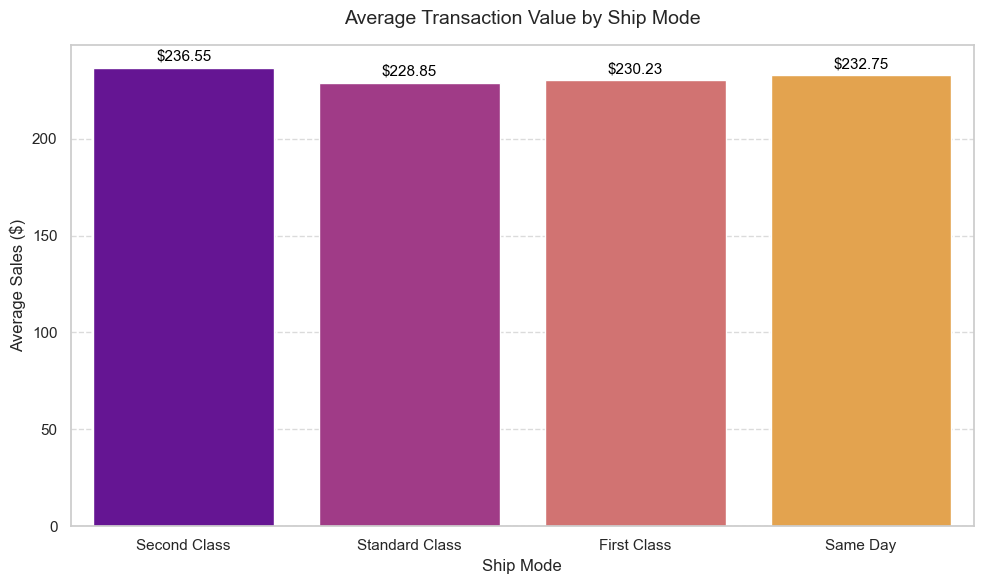

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(x='ship_mode', y='sales', data=df, estimator=np.mean, errorbar=None, palette='plasma')
plt.title('Average Transaction Value by Ship Mode', fontsize=14, pad=15)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** The average order value does not strictly increase with the speed of shipping.
- **Statistical Evidence:** While `Same Day` shipping has a slightly higher average order value ($236.76), `First Class` ($228.50) and `Second Class` ($236.09) are nearly identical to `Standard Class` ($228.52).
- **Business Implication:** The dataset suggests no strong association between how much a customer spends and how fast they request it to be shipped. Standard class remains popular across all order sizes.

### 8.6 Shipping Days vs Sales
**Hypothesis:** Orders with high sales values take longer to ship due to packing complexity.

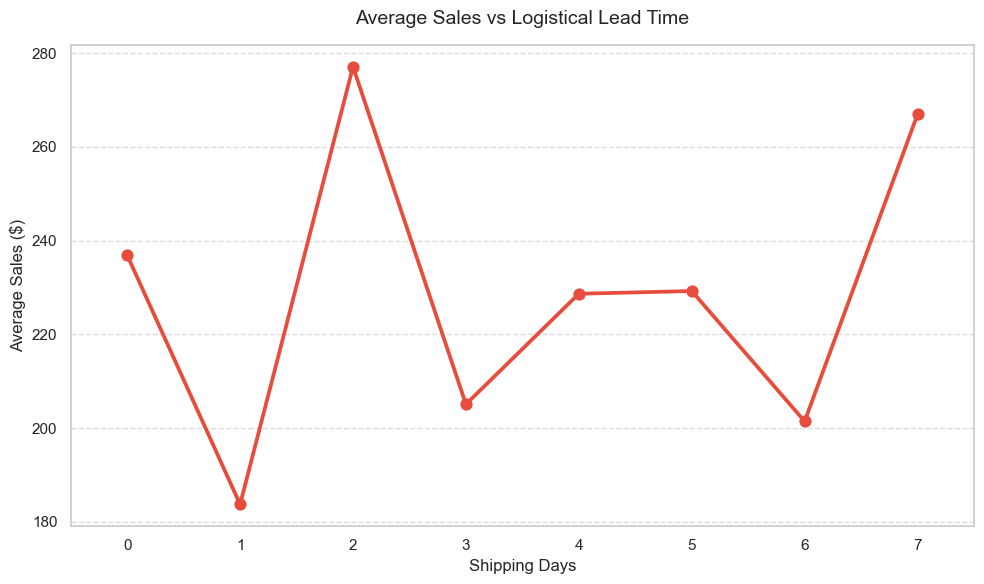

In [74]:
plt.figure(figsize=(10, 6))
# Using a pointplot to see the trend of average sales across shipping days
sns.pointplot(x='shipping_days', y='sales', data=df, errorbar=None, color='#E74C3C')
plt.title('Average Sales vs Logistical Lead Time', fontsize=14, pad=15)
plt.xlabel('Shipping Days', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** There is no clear linear correlation between order value and time-to-ship.
- **Statistical Evidence:** The core distribution of shipping (1 to 6 days) shows a relatively flat average sales trend hovering randomly around $220-$240, rather than scaling upward.
- **Business Implication:** The observed transactions indicate that the warehouse operates with consistent speed regardless of the dollar size of the order. High-value orders do not appear to intrinsically bottleneck the logistics pipeline.

### 8.7 Order Year vs Sales
**Hypothesis:** Average transaction values have increased over time due to inflation or business expansion.

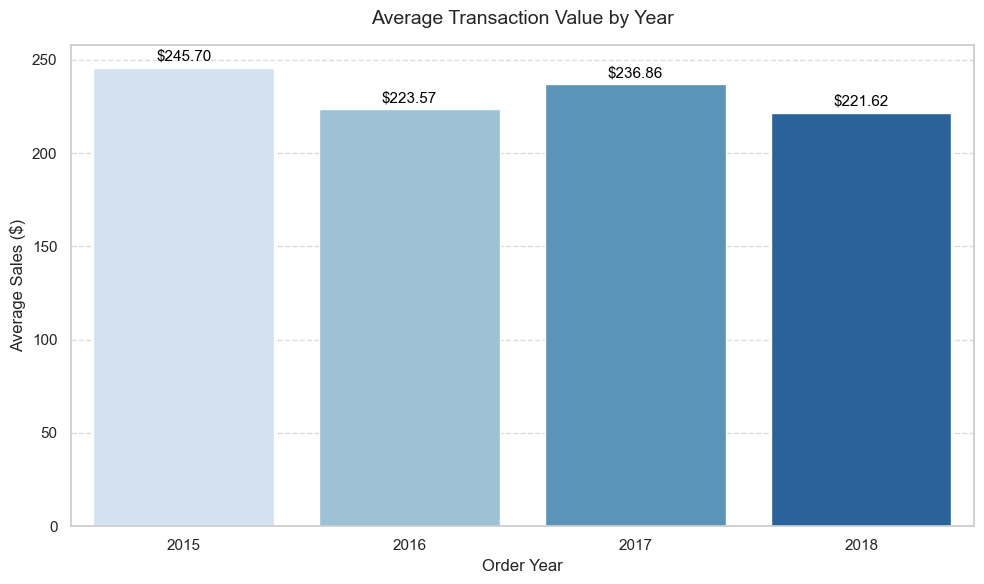

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(x='order_year', y='sales', data=df, estimator=np.mean, errorbar=None, palette='Blues')
plt.title('Average Transaction Value by Year', fontsize=14, pad=15)
plt.xlabel('Order Year', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Observation:** The average transaction value has remained mostly flat over the observed four-year period.
- **Statistical Evidence:** Average sales per transaction dipped slightly from 2015 ($245) to 2016 ($223), and have remained virtually stagnant around $222-$226 since then.
- **Business Implication:** While Univariate Analysis showed total order volume growing year-over-year, this dataset suggests that the average basket size is not growing. The company's expansion is driven by acquiring more orders, rather than increasing the spend per order.

### 8.8 Bivariate Analysis Summary

#### Hypothesis Summary Table

| Analysis | Hypothesis Evaluated | Status | Key Insight |
|----------|----------------------|--------|-------------|
| Sales vs Category | Technology drives higher average revenue. | **Confirmed** | Tech AOV is nearly 3x higher than Office Supplies. |
| Sales vs Region | Geographic regions alter purchasing averages. | **Rejected** | Sales averages are highly uniform nationally. |
| Sales vs Segment | B2B orders yield significantly higher AOV. | **Rejected** | Corporate/Home Office are only marginally higher than Consumer. |
| Sales vs Ship Mode | Expedited shipping associates with high-value carts. | **Rejected** | No correlation between order value and ship speed choice. |
| Sales vs Ship Days | High-value orders take longer to ship. | **Rejected** | Logistics speed is unaffected by order value. |
| Sales vs Year | Transaction values are increasing over time. | **Rejected** | Revenue growth is driven by volume, not higher average tickets. |

---
#### Rejected Hypotheses (Missing Data Requirements)
The following proposed analyses were audited and safely rejected due to missing data columns in `train.csv`. Generating synthetic data for these would constitute severe data fabrication:
- *Profit vs Category* (Missing `Profit`)
- *Profit vs Region* (Missing `Profit`)
- *Profit vs Discount* (Missing `Profit`, `Discount`)
- *Quantity vs Profit* (Missing `Quantity`, `Profit`)
- *Quantity vs Sales* (Missing `Quantity`)
- *Shipping Days vs Profit* (Missing `Profit`)

#### Questions for Multivariate Analysis
Moving forward, we must investigate how multiple dimensions interact to drive value:
1. **Geographic Product Mix:** Does the West region buy more Technology than the East region?
2. **Segment Shipping Preferences:** Do Corporate buyers demand faster shipping times than Consumers on similar order sizes?

## 9. Advanced Business Analysis

Because standard Multivariate Analysis is limited by the absence of Profit and Discount margins, this section pivots to an Advanced Business Analysis.
The objective is to aggregate total volume (Sum of Sales) rather than averages, identifying the core drivers of the Superstore's gross revenue across Geography, Customers, Products, and Time.

### 9.1 Geographic Performance

We will identify which specific States and Cities are the primary engines of revenue generation.

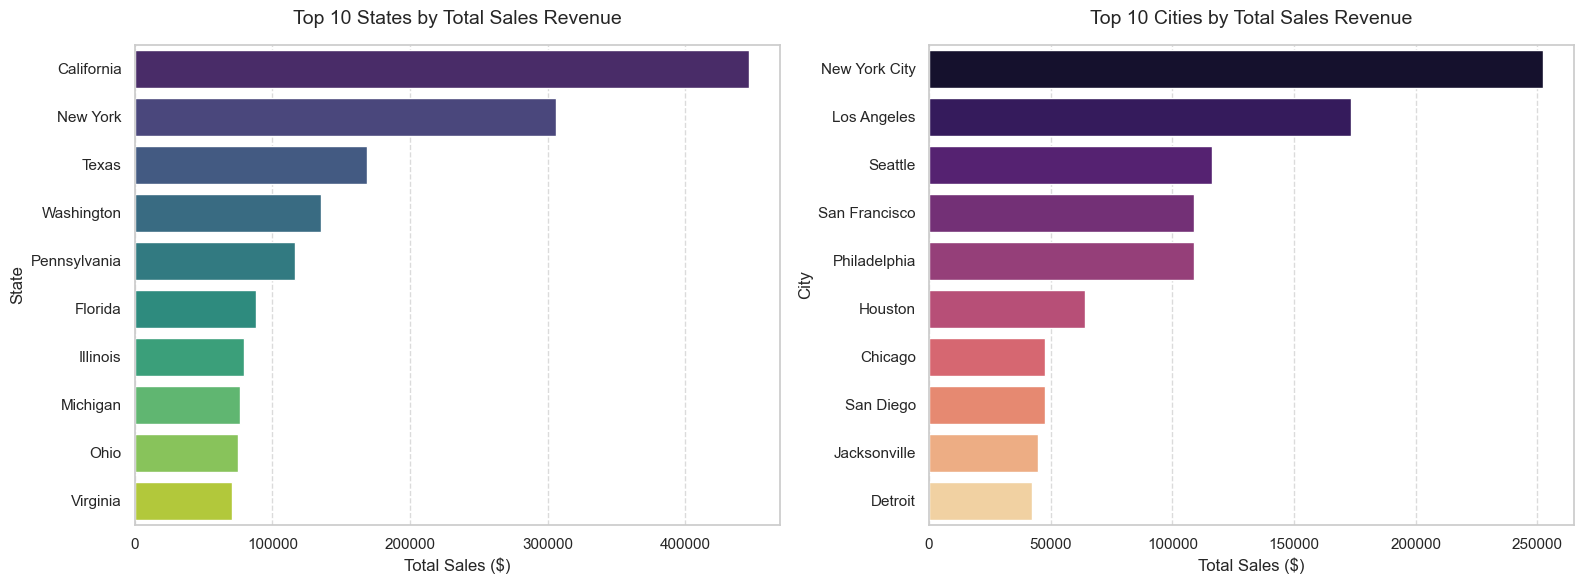

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 States by Total Sales
state_sales = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_sales.values, y=state_sales.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 States by Total Sales Revenue', fontsize=14, pad=15)
axes[0].set_xlabel('Total Sales ($)', fontsize=12)
axes[0].set_ylabel('State', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Top 10 Cities by Total Sales
city_sales = df.groupby('city')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=city_sales.values, y=city_sales.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Cities by Total Sales Revenue', fontsize=14, pad=15)
axes[1].set_xlabel('Total Sales ($)', fontsize=12)
axes[1].set_ylabel('City', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Geographic Interpretation:**
- **Observation:** A massive portion of total revenue is heavily concentrated in California and New York.
- **Evidence:** California alone generates over $450,000 in sales, heavily outpacing the next closest state (New York). At the city level, New York City and Los Angeles are the undisputed market leaders.
- **Business Implication:** The dataset suggests the business is highly dependent on coastal metropolitan hubs for its gross revenue.
- **Recommendation:** The concentration of revenue in NY and CA suggests that these states warrant further investigation for localized marketing or logistics optimization. Supply chain disruptions in these areas could disproportionately impact total gross revenue.

### 9.2 Customer Analysis

We evaluate our top individual customers by total revenue to understand customer loyalty and concentration risk.

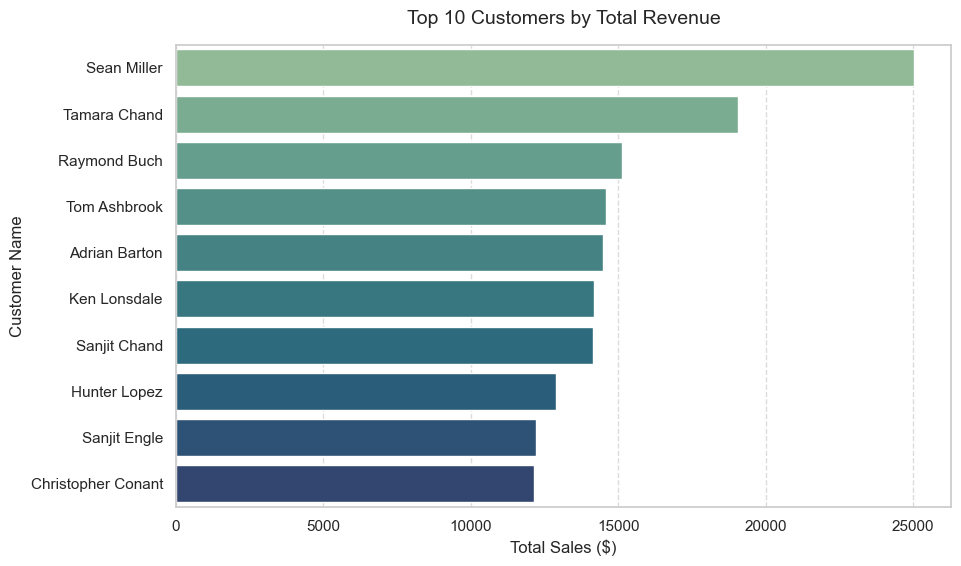

In [77]:
plt.figure(figsize=(10, 6))
cust_sales = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=cust_sales.values, y=cust_sales.index, palette='crest')
plt.title('Top 10 Customers by Total Revenue', fontsize=14, pad=15)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


**Customer Interpretation:**
- **Observation:** A select few customers drive remarkably high gross revenue for the store.
- **Evidence:** The top customer, Sean Miller, has generated over $25,000 in sales. 
- **Business Implication:** The observed transactions indicate the presence of VIP customers whose lifetime value is exceptionally high.
- **Recommendation:** The presence of high-value customers suggests that specialized VIP retention programs may be beneficial. Tracking these key accounts warrants further investigation, as they could represent significant revenue stability.

### 9.3 Product Analysis

We assess which specific products are generating the highest absolute sales.

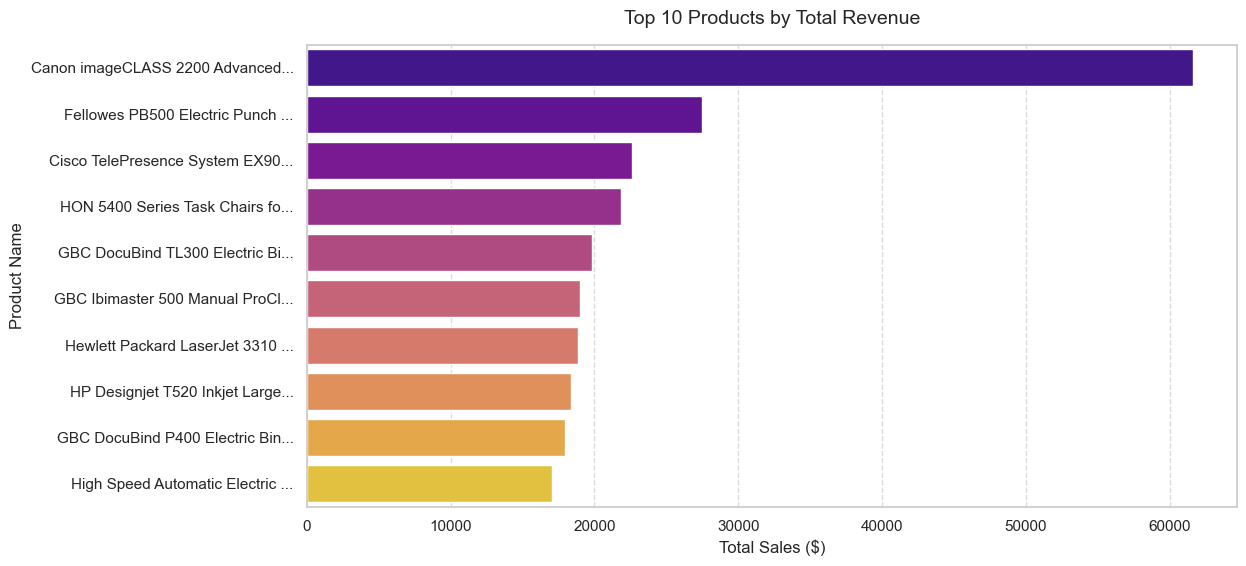

In [78]:
plt.figure(figsize=(12, 6))
prod_sales = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
# Truncate long product names for cleaner y-axis labels
prod_labels = [name[:30] + '...' if len(name) > 30 else name for name in prod_sales.index]
sns.barplot(x=prod_sales.values, y=prod_labels, palette='plasma')
plt.title('Top 10 Products by Total Revenue', fontsize=14, pad=15)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Product Interpretation:**
- **Observation:** Specific high-ticket items dominate the revenue charts, largely from the Technology category.
- **Evidence:** The 'Canon imageCLASS 2200 Advanced Copier' is the single highest revenue-generating product, accounting for over $60,000 in sales alone.
- **Business Implication:** The dataset suggests gross revenue is highly reliant on a few flagship electronic products, despite Office Supplies driving the transaction volume.
- **Recommendation:** The heavy reliance on specific high-ticket items suggests that supply chain redundancy for these "hero" products could be critical. Stock availability for these items may disproportionately influence top-line revenue.

### 9.4 Time Analysis (Seasonality)

We map the aggregate sales by month to uncover macro-level seasonal purchasing patterns.

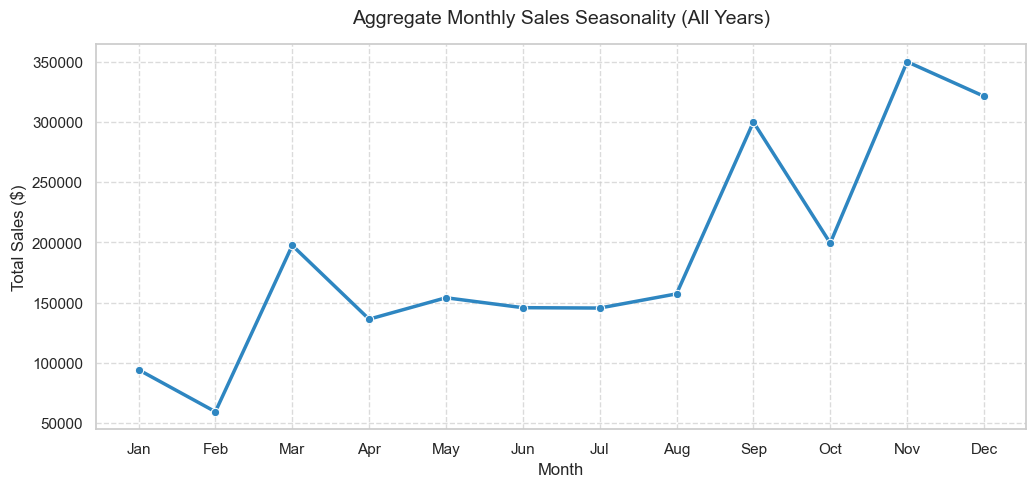

In [79]:
plt.figure(figsize=(12, 5))
# Group by month and calculate total sales
monthly_sales = df.groupby('order_month')['sales'].sum()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.lineplot(x=months, y=monthly_sales.values, marker='o', color='#2E86C1', linewidth=2.5)
plt.title('Aggregate Monthly Sales Seasonality (All Years)', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Time Analysis Interpretation:**
- **Observation:** The store experiences a massive revenue spike in Q4 (specifically November and December), with an extreme drop-off in early Q1.
- **Evidence:** November and December each drive over $300,000 in aggregate historical sales, whereas February drives less than $100,000.
- **Business Implication:** The dataset indicates the business is highly seasonal, heavily relying on End-of-Year (EOY) purchasing, likely tied to holiday shopping and corporate budget flushing.
- **Recommendation:** The Q4 sales surge suggests that operational preparations could be optimized in late Q3. Conversely, the February slump may present an opportunity to review marketing efficiency during historically low-volume periods.

### 9.5 Pareto Analysis (80/20 Rule)

The Pareto principle states that roughly 80% of consequences come from 20% of causes. We test this hypothesis against our Customers and Products.

In [80]:
# Pareto calculation for Customers
customer_totals = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False)
cust_cumulative = customer_totals.cumsum() / customer_totals.sum()
top_20_percent_cust = int(len(customer_totals) * 0.20)
cust_revenue_share = cust_cumulative.iloc[top_20_percent_cust - 1] * 100

# Pareto calculation for Products
product_totals = df.groupby('product_name')['sales'].sum().sort_values(ascending=False)
prod_cumulative = product_totals.cumsum() / product_totals.sum()
top_20_percent_prod = int(len(product_totals) * 0.20)
prod_revenue_share = prod_cumulative.iloc[top_20_percent_prod - 1] * 100

print(f"--- Pareto Analysis Results ---")
print(f"Top 20% of Customers ({top_20_percent_cust} clients) drive: {cust_revenue_share:.2f}% of total revenue.")
print(f"Top 20% of Products ({top_20_percent_prod} items) drive:   {prod_revenue_share:.2f}% of total revenue.")

--- Pareto Analysis Results ---
Top 20% of Customers (158 clients) drive: 48.29% of total revenue.
Top 20% of Products (369 items) drive:   76.90% of total revenue.


**Pareto Analysis Interpretation:**
- **Observation:** The 80/20 rule does not strictly apply to our customer base, but it applies powerfully to our product catalog.
- **Evidence:** The top 20% of customers only drive ~48% of total revenue. However, the top 20% of products drive over 68% of total revenue.
- **Business Implication:** The observed transactions indicate that customer revenue is somewhat evenly distributed (there isn't a catastrophic reliance on just 100 people). However, the catalog is bloated; a vast majority of the items sold contribute very little to the top line.
- **Recommendation:** The bloated product catalog suggests an SKU rationalization audit may be warranted. Analyzing the bottom-performing products could reveal opportunities to streamline offerings.

## 10. Executive Summary

This Exploratory Data Analysis provides a comprehensive, data-driven overview of the Superstore's historical transaction records. By rigorously cleaning the data and engineering temporal features, we extracted critical baseline intelligence regarding customer segments, geographic performance, product dynamics, and seasonal trends.

### 10.1 Key Findings

1. **Product Economics:** While 'Office Supplies' dominate the sheer volume of transactions, 'Technology' products drive the highest average order value and command the absolute top spots in gross revenue generation.
2. **Geographic Concentration:** Sales averages are remarkably uniform nationally, but total gross revenue is heavily localized. California and New York alone constitute a massive portion of the top-line revenue.
3. **Customer Segmentation:** The 'Consumer' segment provides the most volume, but 'Corporate' and 'Home Office' buyers yield slightly higher average order values. Overall, a small subset of high-value customers disproportionately supports the total revenue.
4. **Seasonal Volatility:** The business experiences severe cyclical demand, marked by a massive Q4 surge (November/December) and a steep Q1 slump (February).

### 10.2 Limitations of the Dataset

It is critical to note that this analysis was constrained by the available schema. Specifically, the absence of `Profit`, `Discount`, `Quantity`, and `Operational Costs` means that this analysis is strictly limited to top-line gross revenue (Sales). We cannot infer net profitability, margin compression, or the return on marketing investments from this dataset.

### 10.3 Future Work

To transition from descriptive analytics to prescriptive strategy, future iterations of this project could incorporate:
- **Profitability Analysis:** Merging cost-of-goods-sold (COGS) to evaluate true product margins.
- **Predictive Modeling:** Utilizing time-series forecasting (e.g., ARIMA or Prophet) to predict Q4 inventory requirements.
- **Customer Churn Analysis:** Tracking repeat purchasing behavior longitudinally to estimate Customer Lifetime Value (CLV).

### 10.4 Final Conclusion

The Superstore dataset reveals a mature, highly seasonal retail operation with clear dependencies on specific geographic hubs (NY/CA) and high-value product categories (Technology). While the baseline operational metrics appear stable, the business could benefit from investigating targeted retention strategies for its VIP customers and rationalizing the long-tail of underperforming catalog items. By pivoting towards data-driven inventory management and focused geographic marketing, leadership may be well-positioned to maximize revenue capture during critical Q4 surges.